<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/NA_Tatiana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Criando dados simulados

In [ ]:
from IPython.core.interactiveshell import dis
import pandas as pd
import numpy as np

# Define states and municipalities
states = {
    'São Paulo': ['A', 'B', 'C', 'D'],
    'Minas Gerais': ['X', 'Y'],
    'Rio de Janeiro': ['XXX', 'YYY'],
}

years = range(2000, 2022)

# Create an empty list to store data
data = []

# Generate simulated precipitation data
for state, municipalities in states.items():
    for municipality in municipalities:
        for year in years:
            # Simulate precipitation (e.g., between 500 and 2500 mm/year)
            precipitation = np.random.uniform(500, 2500)
            data.append({
                'Estado': state,
                'Município': municipality,
                'Ano': year,
                'Precipitação (mm)': precipitation
            })

# Create DataFrame
df = pd.DataFrame(data)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Estado             176 non-null    object 
 1   Município          176 non-null    object 
 2   Ano                176 non-null    int64  
 3   Precipitação (mm)  176 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.6+ KB
None


# Criando índices de dados faltantes

In [ ]:
missing_indices = np.random.choice(df.index, size=int(len(df) * 0.01), replace=False)

print(missing_indices)

[125]


# Determinando se há dados faltantes no banco de dados

In [ ]:
df.loc[missing_indices, 'Precipitação (mm)'] = np.nan
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Estado             176 non-null    object 
 1   Município          176 non-null    object 
 2   Ano                176 non-null    int64  
 3   Precipitação (mm)  175 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 5.6+ KB
None


# Há dados faltantes por Estado, Município e Ano no conjunto de dados? (Específico)

In [ ]:
missing_counts_summary = df[df['Precipitação (mm)'].isnull()].groupby(['Estado', 'Município', 'Ano']).size().reset_index(name='NA')

if not missing_counts_summary.empty:
    print("Tabela Resumo de Dados Faltantes por Estado, Município e Ano:")
    display(missing_counts_summary)
else:
    print("Não há dados faltantes por Estado, Município e Ano no conjunto de dados.")

Tabela Resumo de Dados Faltantes por Estado, Município e Ano:


,Estado,Município,Ano,NA
0,Minas Gerais,Y,2015,1


# Há dados faltantes por Estado, Município e Ano no conjunto de dados? (Geral)

In [ ]:
completion_counts = df.groupby(['Estado', 'Município'])['Precipitação (mm)'].agg(['count', 'size']).reset_index()
completion_counts['Porcentagem Completa (%)'] = (completion_counts['count'] / completion_counts['size']) * 100
completion_counts['Porcentagem Faltante (%)'] = 100 - completion_counts['Porcentagem Completa (%)']
completion_counts.rename(columns={'count': 'Dados Completos', 'size': 'Total Dados'}, inplace=True)

print("Porcentagem de Dados Completos e Faltantes por Estado e Município:")
display(completion_counts)

Porcentagem de Dados Completos e Faltantes por Estado e Município:


,Estado,Município,Dados Completos,Total Dados,Porcentagem Completa (%),Porcentagem Faltante (%)
0,Minas Gerais,X,22,22,100.000000,0.000000
1,Minas Gerais,Y,21,22,95.454545,4.545455
2,Rio de Janeiro,XXX,22,22,100.000000,0.000000
3,Rio de Janeiro,YYY,22,22,100.000000,0.000000
4,São Paulo,A,22,22,100.000000,0.000000
5,São Paulo,B,22,22,100.000000,0.000000
6,São Paulo,C,22,22,100.000000,0.000000
7,São Paulo,D,22,22,100.000000,0.000000


# Porcentagem de Dados Completos e Faltantes por Estado e Município

# Estados e Municípios sem dados faltantes

In [ ]:
no_missing_data = completion_counts[completion_counts['Porcentagem Faltante (%)'] == 0][['Estado', 'Município']]

if not no_missing_data.empty:
    print("Estados e Municípios sem dados faltantes:")
    display(no_missing_data)
else:
    print("Não há estados ou municípios sem dados faltantes completos.")

Estados e Municípios sem dados faltantes:


,Estado,Município
0,Minas Gerais,X
2,Rio de Janeiro,XXX
3,Rio de Janeiro,YYY
4,São Paulo,A
5,São Paulo,B
6,São Paulo,C
7,São Paulo,D


# Selecionando dados completos do banco de dados geral


In [ ]:
df_complete = pd.merge(df, no_missing_data, on=['Estado', 'Município'], how='inner')



In [ ]:
unique_combinations = df_complete[['Estado', 'Município']].drop_duplicates()
print("Unique 'Estado' and 'Município' combinations in df_complete:")
display(unique_combinations)

Unique 'Estado' and 'Município' combinations in df_complete:


,Estado,Município
0,São Paulo,A
22,São Paulo,B
44,São Paulo,C
66,São Paulo,D
88,Minas Gerais,X
110,Rio de Janeiro,XXX
132,Rio de Janeiro,YYY


In [ ]:
print(f"Total de linhas no novo DataFrame: {len(df_complete)}")


Total de linhas no novo DataFrame: 154


In [ ]:
print(df_complete.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Estado             154 non-null    object 
 1   Município          154 non-null    object 
 2   Ano                154 non-null    int64  
 3   Precipitação (mm)  154 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.9+ KB
None


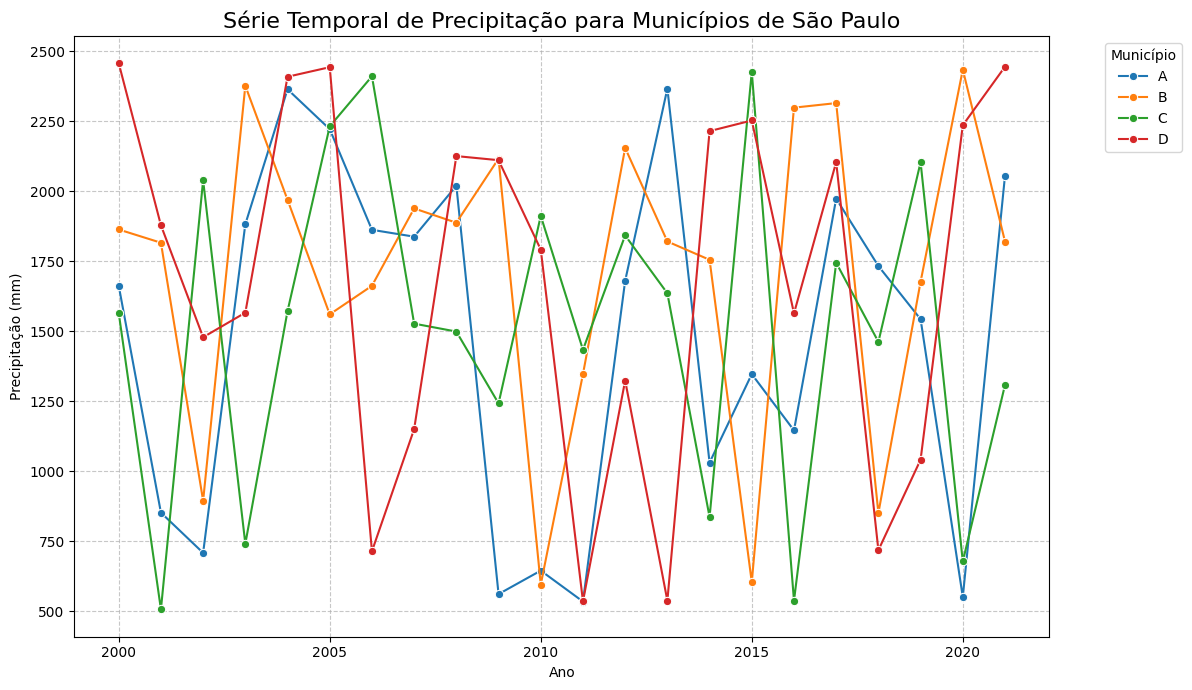

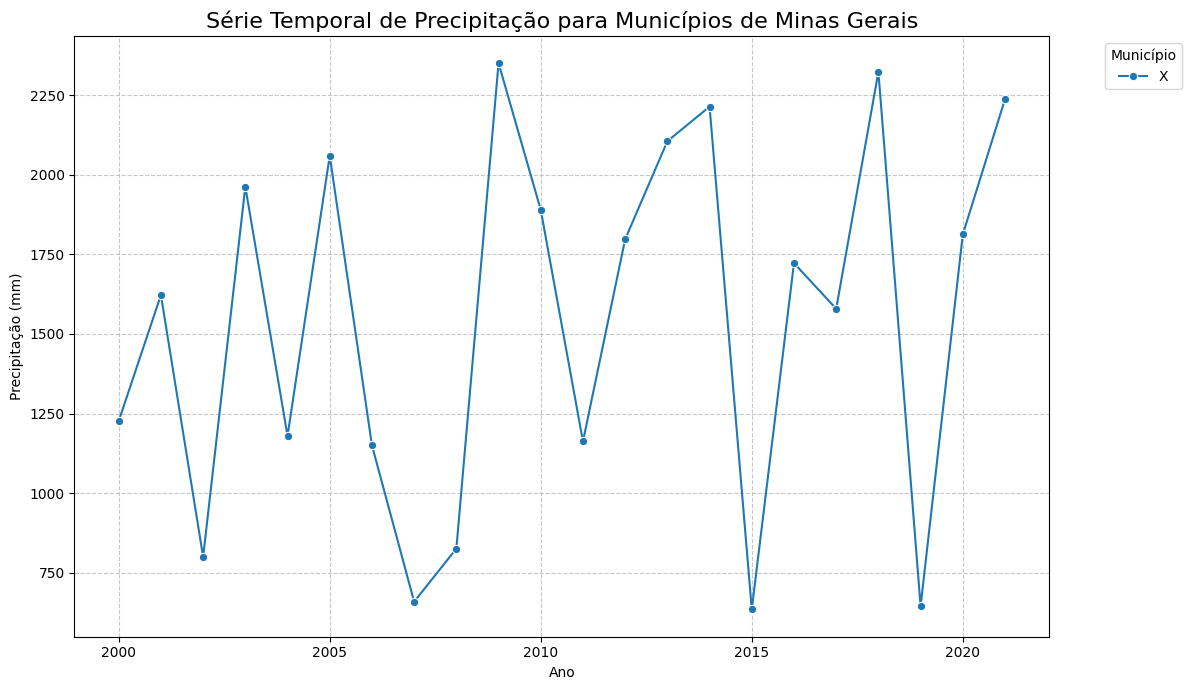

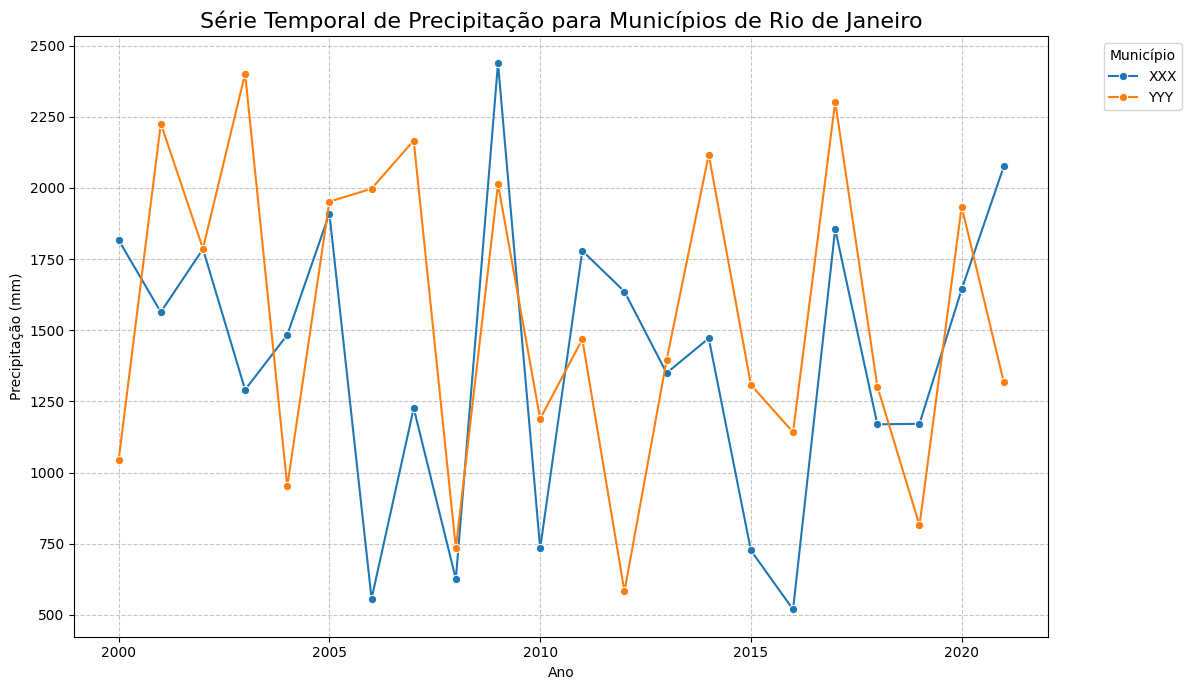

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Obter a lista de estados únicos do DataFrame df_complete
states_in_df_complete = df_complete['Estado'].unique()

# Iterar sobre cada estado e gerar o gráfico de série temporal
for state in states_in_df_complete:
    # Filtrar o DataFrame para o estado atual
    df_state = df_complete[df_complete['Estado'] == state].copy()

    # Verificar se há dados para o estado antes de plotar
    if not df_state.empty:
        plt.figure(figsize=(12, 7))
        sns.lineplot(
            data=df_state,
            x="Ano",
            y="Precipitação (mm)",
            hue="Município",
            marker='o',
            palette='tab10'
        )

        plt.title(f"Série Temporal de Precipitação para Municípios de {state}", fontsize=16)
        plt.xlabel("Ano")
        plt.ylabel("Precipitação (mm)")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(title="Município", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Não há dados completos para o estado de {state} em df_complete para gerar o gráfico.")